# In-class Problem

Keep in mind that we are not trying to make any materials-specific conclusions from this excersise, So let's not get too stuck on what materials-decisions we have to make for the model to be meaningful (You can get back to that at a later date) 

The main point of this exercise is to see how we can run a cross-validation on a dataset, and how doing this manually gives rise to a complication in standardizing the dataset.

We will be using **[Logistic Regression](week06-6_logistic_regression_intro.ipynb)** (which is actually a classification model).

The dataset is accessible online, so we don't have to download it. 



In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score,KFold
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset with the correct delimiter

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00198/Faults.NNA"

columns = ["X_Minimum", "X_Maximum", "Y_Minimum", "Y_Maximum", "Pixels_Areas", "X_Perimeter",
           "Y_Perimeter", "Sum_of_Luminosity", "Minimum_of_Luminosity", "Maximum_of_Luminosity",
           "Length_of_Conveyer", "TypeOfSteel_A300", "TypeOfSteel_A400", "Steel_Plate_Thickness",
           "Edges_Index", "Empty_Index", "Square_Index", "Outside_X_Index", "Edges_X_Index",
           "Edges_Y_Index", "Outside_Global_Index", "LogOfAreas", "Log_X_Index", "Log_Y_Index",
           "Orientation_Index", "Luminosity_Index", "SigmoidOfAreas", "Pastry", "Z_Scratch",
           "K_Scatch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

data = pd.read_csv(url, delimiter='\t', names=columns)

In [5]:
# Check the first few rows to verify the data
data.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [4]:
len(data)

1941

In [7]:
# Check for any missing values
print("Missing values in the dataset:\n", data.isnull().sum())

Missing values in the dataset:
 X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scatch                 0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64


The .iloc[] function in Python is used for integer-location based indexing in pandas DataFrames and Series. It allows you to select rows and columns by their integer position (i.e., the row and column number). 

In [8]:
data1 = data.iloc[1:4, 2:5]  # row - 1 to 3, and column - 2 to 4 (remember python starts at 0)
print(data1)

   Y_Minimum  Y_Maximum  Pixels_Areas
1    2538079    2538108           108
2    1553913    1553931            71
3     369370     369415           176


In [9]:
data2 = data.iloc[:,:1]   #returns the first column
print(data2)

      X_Minimum
0            42
1           645
2           829
3           853
4          1289
...         ...
1936        249
1937        144
1938        145
1939        137
1940       1261

[1941 rows x 1 columns]


In [10]:
# Define features and target
X = data.iloc[:,:27]  # All columns except the last 7 are features
y = data['Pastry']  # Let's use 'Pastry' as the target

In [11]:
X.shape

(1941, 27)

In [12]:
X.head()  #Just to see what the data looks like

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000


In [13]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Pastry, dtype: int64

In [14]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   #Fit and transform the X data

In [15]:
# Initialize the model
model = LogisticRegression(max_iter=200)

In [16]:
#Let's do the cross validation
cv_scores = cross_val_score(model, X_scaled, y, cv=10)

In [17]:
# Print the cross-validation scores
print("Cross-validation scores: ", cv_scores)
print("Mean cross-validation score: ", np.mean(cv_scores))

Cross-validation scores:  [0.96410256 0.94329897 0.95876289 0.89690722 0.93298969 0.91237113
 0.84020619 0.89690722 0.95360825 0.91237113]
Mean cross-validation score:  0.9211525244514936


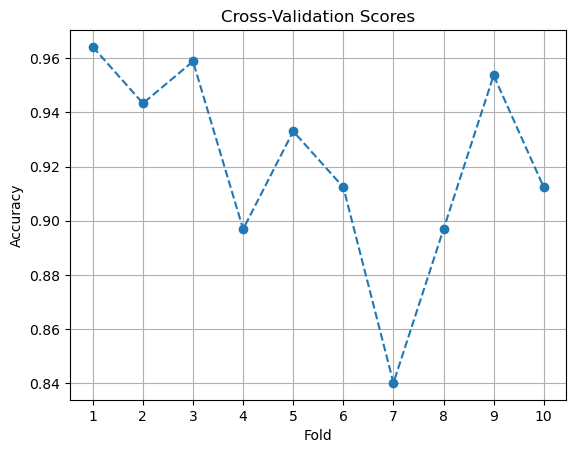

In [18]:
# Plot the cross-validation scores
plt.figure()
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='--')
plt.title('Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, len(cv_scores) + 1))
plt.grid(True)
plt.show()


Note that everytime you run this, the output is the same. The Cross validation operation here splits the data into the same folds each time.

If you want to randomize your split, then you have to specify that.

In [19]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X_scaled, y, cv=5)


In [20]:
# Perform 5-fold cross-validation with a specific random_state
kf = KFold(n_splits=5, shuffle=True, random_state=112)
cv_scores_2 = cross_val_score(model, X_scaled, y, cv=kf)
print("Cross-validation scores (random_state=42):", cv_scores_2)

Cross-validation scores (random_state=42): [0.91773779 0.93041237 0.93556701 0.94072165 0.93556701]


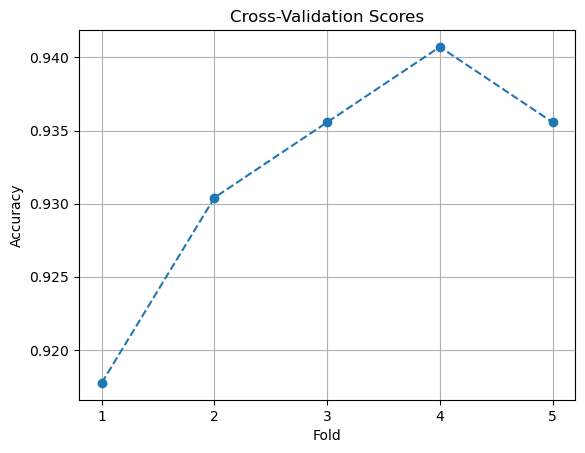

In [21]:
# Plot the cross-validation scores
plt.figure()
plt.plot(range(1, len(cv_scores_2) + 1), cv_scores_2, marker='o', linestyle='--')
plt.title('Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, len(cv_scores_2) + 1))
plt.grid(True)
plt.show()

# ⚠️ Important

## 📏 Why Scaling should come After the Split 

We know that data scaling is part of data pre-processing, but it should only be done **after the train-test  split**, and before feeding into the model.
Which means, once you split your data into training and testing, you will need to scale the training and testing datasets separately!

**1. Why scaling has to happen after the train-test split**

Scaling a feature - whether by standardizing it (subtracting the mean, dividing by the standard deviation) or min-max scaling it into a fixed range - it is not a fixed, universal transformation like converting inches to centimeters. This is a transformation learned from the data: the scaler has to first look at your feature values to compute a mean and a standard deviation, or a minimum and a maximum, before it can rescale anything.

This creates a small problem: scaling involves fitting something to data, and the moment you fit something to data - you allow the fit to know the structure or boundaries of your data. So, if you do the train-test split after fitting the scaler, the structure or boundaries of the test set will be known to the model.

The purpose of a test set is to stand in for data the model will encounter in the future - data that doesn't exist yet at training time. If you compute your scaling statistics (mean, standard deviation, min, max, whatever it is) using the full dataset - training and test rows together - you've quietly let information about the test set influence something that happens before the model has even started training. The test set's range, its outliers, its particular mean: all of that has **leaked** into the numbers the model is trained on, even though, conceptually, none of it should have been visible yet.

## 💧

This is called data leakage, and it's a subtler failure mode than most beginners expect, because nothing about it looks wrong. The code runs. The numbers come out. The model even tends to perform better than it honestly should, because the test set is no longer quite as "unseen" as it's supposed to be - some of its information already shaped the preprocessing. That's arguably the most dangerous kind of bug: one that inflates your model.

So, to avoid this, we need to do some extra work. 

Fit the scaler using only the training data, and then apply that already-fitted scaler to both the training data and the test data. The test set gets rescaled using statistics that came exclusively from the training set - it never gets to contribute a single number to how the scaling itself is defined. This is closer to reality: when the model is eventually deployed, it will encounter new data one point (or batch) at a time, with no opportunity to recompute "what the mean of everything looks like" using data from the future. Fitting the scaler on training data alone is what actually simulates that constraint honestly.

And to be clear, this principle isn't unique to scaling. It applies to any preprocessing step that learns something from the data before modeling - imputing missing values using a column's mean, applying PCA, selecting features based on correlation with the target, encoding categories based on their frequency. Every one of these needs to be fit on the training portion only, then applied unchanged to the test portion. Scaling is just the simplest and most common example of the pattern.

**2. Why this gets complicated once cross-validation enters the picture**

A single train-test split only requires you to get this right once: fit the scaler on the training set, apply it to both pieces, done. Cross-validation multiplies the problem.

Recall what k-fold cross-validation actually does: it splits the training data into k roughly equal chunks (folds), then trains k separate models, each time holding out one fold as a stand-in validation set and training on the remaining k-1 folds. Every fold gets a turn as the "test set" for one round.

Here's where it gets tricky. If you scale the data once, up front, before handing it to the cross-validation loop, you've made the same leakage mistake as before - except now it happens k times over, once per fold, since every fold's "held-out" portion was already influenced by statistics computed using data that included that very fold. The correct approach requires something much more disciplined: for each of the k rounds, you need to fit a brand-new scaler using only that round's k-1 training folds, and then use that scaler to transform both those training folds and the one held-out fold. Every round gets its own separately-fitted scaler, because every round has a slightly different set of training data 😨.

Think about what that actually demands if you were to do it by hand. You'd need to manually loop over each fold, split the data into the (k-1)-fold training portion and the 1-fold validation portion, fit a fresh scaler on the training portion only, transform both pieces with it, fit the model on the scaled training portion, evaluate it on the scaled validation portion, and repeat - correctly re-doing this from scratch every single round. And that's before you've introduced hyperparameter tuning: if you're running a grid search over, say, 20 hyperparameter combinations with 5-fold cross-validation, the "fit a fresh scaler on just the right subset of data" step now needs to happen correctly 100 separate times, nested inside two loops, with no shortcuts and no reuse of a scaler fit on the wrong slice of data 😭😭😭.


**3. This is the problem Pipeline exists to solve**

The good news is that *Python has a way to deal with this!!* 🥳 

This is the motivation for scikit-learn's Pipeline object. At a high level, a pipeline lets you chain preprocessing steps and a final model together into a single object that behaves like one unit. You call .fit() once, on the pipeline as a whole, and it takes care of fitting each internal step - the scaler, and then the model - in the correct order, using only the data it was actually handed.

The payoff is exactly the discipline we just described, but automatic. When a pipeline is passed into a cross-validation routine, scikit-learn refits the entire pipeline - scaler included - separately for each fold, using only that fold's training data, without you writing a single manual loop to enforce it. The same object works whether you're doing one simple train-test split or a full grid search across dozens of hyperparameter combinations and multiple folds; the correct "fit only on the training portion" behavior is baked into how the pipeline works, rather than something you have to remember to re-implement correctly every time.

In other words, a pipeline turns "preprocessing plus modeling" into a single, self-consistent step, and it takes care of keeping track of each complicated step. Let's see how to construct one, and how it lets scaling, cross-validation, and hyperparameter search all work together correctly without the manual bookkeeping we just walked through.

In [22]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,KFold

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00198/Faults.NNA"
columns = ["X_Minimum", "X_Maximum", "Y_Minimum", "Y_Maximum", "Pixels_Areas", "X_Perimeter",
           "Y_Perimeter", "Sum_of_Luminosity", "Minimum_of_Luminosity", "Maximum_of_Luminosity",
           "Length_of_Conveyer", "TypeOfSteel_A300", "TypeOfSteel_A400", "Steel_Plate_Thickness",
           "Edges_Index", "Empty_Index", "Square_Index", "Outside_X_Index", "Edges_X_Index",
           "Edges_Y_Index", "Outside_Global_Index", "LogOfAreas", "Log_X_Index", "Log_Y_Index",
           "Orientation_Index", "Luminosity_Index", "SigmoidOfAreas", "Pastry", "Z_Scratch",
           "K_Scatch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

data = pd.read_csv(url, delimiter='\t', names=columns)

X = data.iloc[:, :-7]  # All columns except the last 7 are features
y = data['Pastry']  # Let's use 'Pastry' as the target


In [23]:
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Standardize the data
    ('classifier', LogisticRegression(max_iter=200))  # Step 2: Apply Logistic Regression
])

# Perform cross-validation using the pipeline
cv_scores = cross_val_score(pipeline, X, y, cv=5)

#Randomizing
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_2 = cross_val_score(pipeline, X, y, cv=kf)
print("Cross-validation scores (random_state=42):", cv_scores_2)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))

Cross-validation scores (random_state=42): [0.93059126 0.93814433 0.90721649 0.92268041 0.94329897]
Cross-validation scores: [0.93059126 0.93041237 0.92268041 0.83505155 0.93041237]
Mean cross-validation score: 0.9098295921342061


In [24]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(max_iter=200))
])

# Define the parameter grid
param_grid = {
    'classifier__C': [0.1, 1, 10],  # Regularization strength for Logistic Regression
    'classifier__solver': ['liblinear', 'lbfgs']  # Solvers for Logistic Regression
}

# Perform grid search using the pipeline
grid_search = GridSearchCV(pipeline, param_grid, cv=5)
grid_search.fit(X, y)

# Print the best parameters and the best score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters found: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Best cross-validation score: 0.9113759838867834
